In [19]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import Subset

from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
from random import randrange
import math

## **Data loading**

In [20]:
NUM_CLASSES = 6
NUM_SUBJECTS = 30
NUM_CHANNELS = 9
BATCH_SIZE = 64

TRAINING_SUBJECTS = 21
VALIDATION_SPLIT = 0.2


activity_labels = {
    0: "WALKING",
    1: "WALKING_UPSTAIRS",
    2: "WALKING_DOWNSTAIRS",
    3: "SITTING",
    4: "STANDING",
    5: "LAYING"
}

data_path = {
    "train": "../data/UCI-HAR/train/",
    "test": "../data/UCI-HAR/test/"
}

signals_path = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z"
]


def split_for_validation (train_dataset):
    val_subjects_split = math.floor(VALIDATION_SPLIT * TRAINING_SUBJECTS)
    train_subjects = np.loadtxt(data_path["train"] + "subject_train.txt").astype("int")

    counter = 0
    curr_subj = 0
    train_split_start = 0
    for subj in train_subjects:
        train_split_start += 1
        if subj != curr_subj:
            curr_subj = subj
            counter += 1
        if counter == val_subjects_split + 1:
            break

    validation_subset = Subset(train_dataset, [i for i in range(0, train_split_start)])
    train_subset = Subset(train_dataset, [i for i in range (train_split_start, train_dataset.__len__())])

    return (train_subset, validation_subset)


class HARDataset (Dataset):
    def __init__ (self, type):
        self.labels = np.loadtxt(data_path[type] + "y_" + type + ".txt").astype("int")
        self.subjects = np.loadtxt(data_path[type] + "subject_" + type + ".txt").astype("int")

        for idx in range(0, len(signals_path)):
            signals = np.loadtxt(data_path[type] + "Inertial Signals/" + signals_path[idx] + "_" + type + ".txt").astype("float32")
            if idx > 0:
                self.data = np.dstack((self.data, signals))
            else:
                self.data = signals

    def __len__ (self):
        return len(self.labels)

    def __getitem__ (self, idx):
        # item: [128, 9]
        item = self.data[idx, :, :]
        item = np.transpose(item)
        label = torch.tensor(self.labels[idx] - 1, dtype=torch.long)

        return item, label
    

train_dataset = HARDataset("train")

train_subset, validation_subset = split_for_validation(train_dataset)
train_dataloader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
validation_dataloader = DataLoader(validation_subset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = HARDataset("test")
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## **Data stats and plottings**

PREVIOUS ACTIVITY: LAYING
CURRENT ACTIVITY: LAYING
NEXT ACTIVITY: WALKING


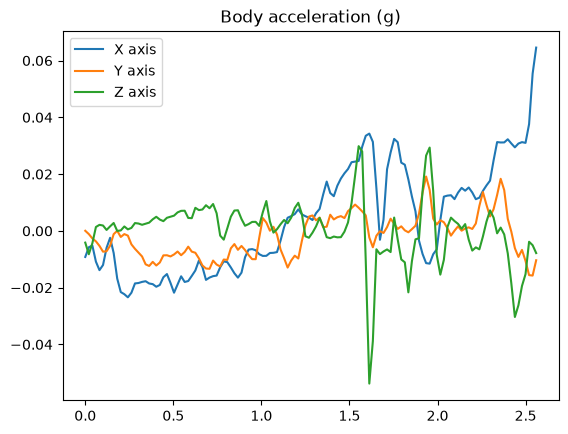

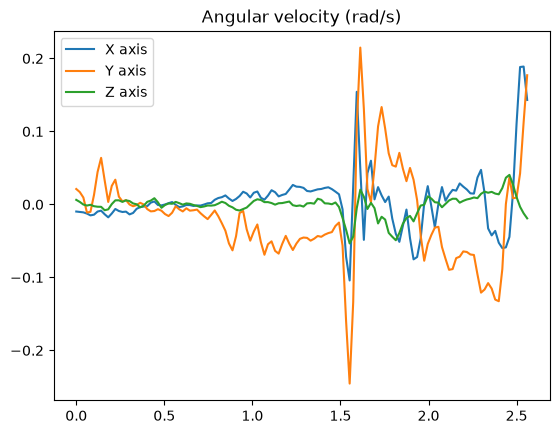

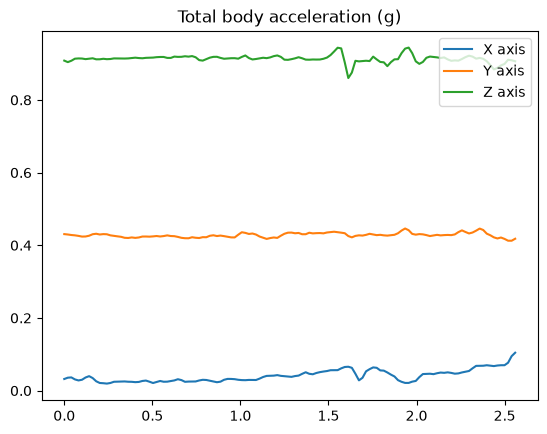

In [21]:

TRAIN_SAMPLES = train_dataset.__len__()
TEST_SAMPLES = test_dataset.__len__()


x = np.linspace(0, 2.56, 128)

# Getting a random sample from the training dataset
rand_idx = randrange(TRAIN_SAMPLES)
item = (train_dataset.__getitem__(rand_idx))
y = item[0]

# Getting the activity related to that sample
activity_idx = item[1].item()
activity = activity_labels[activity_idx]

# Getting the subject related to that sample
subject = train_dataset.subjects[rand_idx].item()


# Printing the activity carried out in the previous timestep (if related to the same subject)
if rand_idx > 0:
    prev_activity_idx = (train_dataset.__getitem__(rand_idx - 1))[1].item()
    prev_subject = train_dataset.subjects[rand_idx - 1].item()
    if prev_subject == subject:
        print("PREVIOUS ACTIVITY:", activity_labels[prev_activity_idx])

print("CURRENT ACTIVITY:", activity)

# Printing the activity carried out in the  next timestep (if related to the same subject)
if rand_idx < TRAIN_SAMPLES - 1:
    next_activity_idx = (train_dataset.__getitem__(rand_idx + 1))[1].item()
    next_subject = train_dataset.subjects[rand_idx + 1].item()
    if next_subject == subject:
        print("NEXT ACTIVITY:", activity_labels[next_activity_idx])


# Plotting the acceleration and angular velocity related to the chosen sample
for i in range(0, NUM_CHANNELS, 3):
    if i == 0: plt.title("Body acceleration (g)")
    if i == 3: plt.title("Angular velocity (rad/s)")
    if i == 6: plt.title("Total body acceleration (g)")

    plt.plot(x, y[i], label="X axis")
    plt.plot(x, y[i + 1], label="Y axis")
    plt.plot(x, y[i + 2], label="Z axis")
    plt.legend()
    plt.show()

## **Model definition**
A simple 1-dimensional CNN consisting of the following modules (with the related input dimension variation):<br>
- **Input**: `[N, 9, 128]`

**First convolutional module**
- **Conv1**: `[N, 9, 128] -> [N, 16, 124]`
- **Activation**: no change
- **Pooling**: `[N, 16, 124] -> [N, 16, 62]`
- **Batch norm**: no change

**Second convolutional module**
- **Conv2**: `[N, 16, 62] -> [N, 8, 60]`
- **Activation**: no change
- **Pooling**: `[N, 8, 60] -> [N, 8, 30]`
- **Batch norm**: no change

**Upstream classification module**
- **Glob. avg. poling**: `[N, 8, 30] -> [N, 8, 1]`
- **Flatten**: `[N, 8, 1] -> [N, 8]`
- **Dropout**: no change
- **Dense**: `[N, 8] -> [N, 6]`

*Note*: `N` = batch size.

In [22]:
LEARNING_RATE = 5e-4

class BaselineModel (nn.Module):
    def __init__ (self, out_classes):
        super().__init__()

        self.conv1 = nn.Conv1d(in_channels=NUM_CHANNELS, out_channels=16, kernel_size=5)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=8, kernel_size=3)
        self.pooling = nn.MaxPool1d(kernel_size=2)
        self.globAvgPooling = nn.AdaptiveAvgPool1d(1)
        self.dense2 = nn.Linear(in_features=8, out_features=16)
        self.dense = nn.Linear(in_features=16, out_features=out_classes)

        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.batchNorm1 = nn.BatchNorm1d(num_features=16, affine=True)
        self.batchNorm2 = nn.BatchNorm1d(num_features=8, affine=True)

    def forward (self, x):
        x = self.batchNorm1(self.pooling(self.activation(self.conv1(x))))
        x = self.batchNorm2(self.pooling(self.activation(self.conv2(x))))
        x = self.globAvgPooling(x)
        x = self.dropout(torch.flatten(x, 1))
        x = self.dropout(self.dense2(x))
        x = self.dense(x)
        
        return x


model = BaselineModel(NUM_CLASSES)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

## **Model evalution and metrics**

In [23]:
def batch_accuracy (outputs, labels):
    part_acc = 0

    for i in range(0, (outputs.size())[0]):
        y_pred = torch.argmax(outputs[i])

        if y_pred == labels[i]:
            part_acc += 1
        
    return part_acc


def evaluate (model, dataloader):
    acc = 0
    model.eval()

    with torch.no_grad():
        for _, data in enumerate(dataloader):
            inputs, labels = data
            outputs = model(inputs)
            acc += batch_accuracy(outputs, labels)

    return round((acc / len(dataloader.dataset) * 100), 2)


def plot_conf_matrix (model, dataloader, title):
    conf_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES))

    with torch.no_grad():
        for _, data in enumerate(dataloader):
            inputs, labels = data
            outputs = model(inputs)

            for i in range(0, (outputs.size())[0]):
                y_pred = torch.argmax(outputs[i])
                y_actual = labels[i]

                conf_matrix[y_actual][y_pred] += 1

    labels = ["WALKING", "WALKING UPSTAIRS", "WALKING DOWNSTAIRS", "SITTING", "STANDING", "LAYING"]

    _, ax = plt.subplots()
    ax.xaxis.set_label_position("top")
    ax.yaxis.set_label_position("right")
    sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="g", xticklabels=labels, yticklabels=labels, cbar=False)
    plt.title(title, fontsize=20)
    plt.xlabel("Predicted class", fontsize=14)
    plt.ylabel("Actual class", fontsize=14)
    plt.show()


"""def plot_acc_per_subj (model, dataloader):
    subjects = []
    accuracy = []

    with torch.no_grad():
        for _, data in enumerate(dataloader):
            inputs, labels = data
            outputs = model(inputs)

            for i in range(0, (outputs.size())[0]):
                y_pred = torch.argmax(outputs[i])
                y_actual = labels[i]"""

                

'def plot_acc_per_subj (model, dataloader):\n    subjects = []\n    accuracy = []\n\n    with torch.no_grad():\n        for _, data in enumerate(dataloader):\n            inputs, labels = data\n            outputs = model(inputs)\n\n            for i in range(0, (outputs.size())[0]):\n                y_pred = torch.argmax(outputs[i])\n                y_actual = labels[i]'

## **Training loop**

Starting point
Train accuracy: 18.99%
Validation accuracy: 17.33%



Training on 100 epochs: 100%|██████████| 100/100 [02:45<00:00,  1.66s/it]


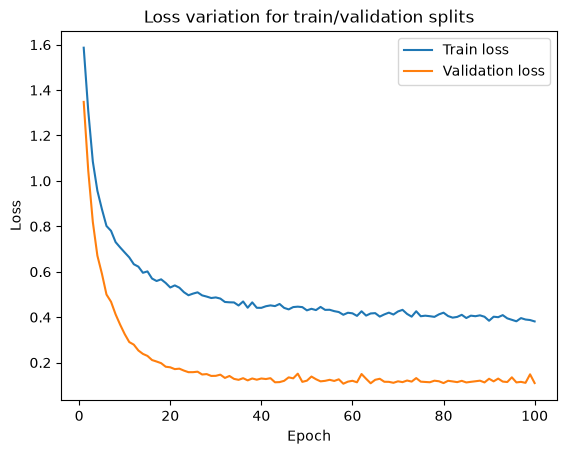

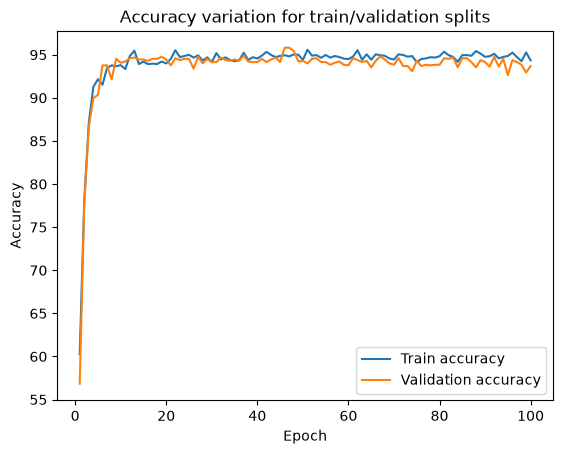

Best validation loss: 0.107
Final validation accuracy:  94.22%


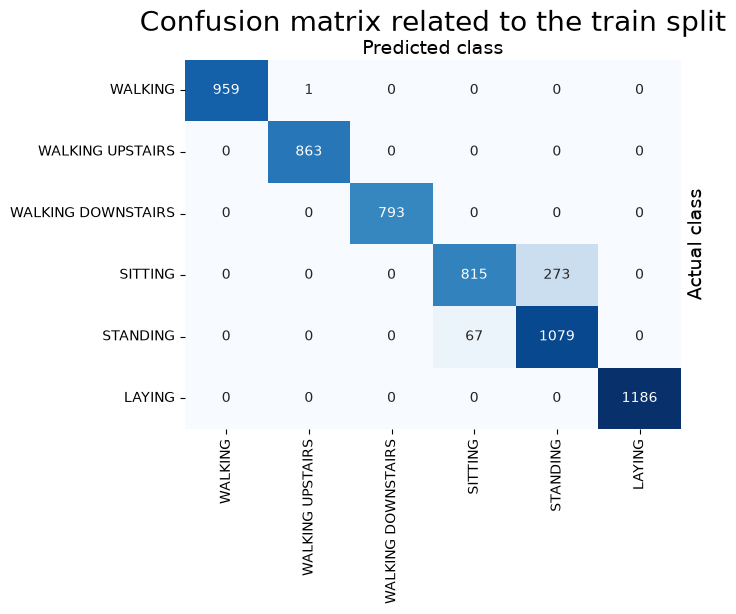

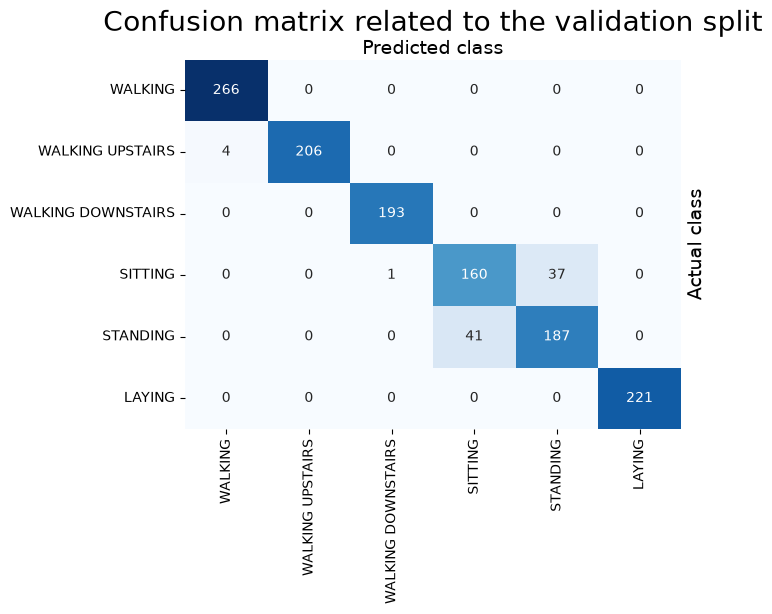

In [24]:
NUM_EPOCHS = 100


print("Starting point")
print("Train accuracy: {0}%".format(evaluate(model, train_dataloader)))
print("Validation accuracy: {0}%\n".format(evaluate(model, validation_dataloader)))

y_train_loss = []
y_val_loss = []
y_train_acc = []
y_val_acc = []

best_val_loss = float("inf")
final_val_acc = 0
best_model = None


# Iterating through the epochs
for epoch in tqdm(range(0, NUM_EPOCHS), desc="Training on " + str(NUM_EPOCHS) + " epochs"):
    #print("EPOCH {0}".format(epoch + 1), end="")

    # The model is set in training mode
    model.train()

    train_loss = 0
    # Iterating through the batches
    for i, data in enumerate(train_dataloader):
        inputs, labels = data
        
        # The optimization gradients are reset
        optimizer.zero_grad()

        # The current batch is forwarded to the network
        outputs = model(inputs)
        
        loss = criterion(outputs, labels)
        train_loss += loss.item()

        # Backpropagation 
        loss.backward()
        # Parameters update
        optimizer.step()

    # The model is set in evaluation mode
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for i, data in enumerate(validation_dataloader):
            inputs, labels = data
            outputs = model(inputs)

            loss = criterion(outputs, labels)
            val_loss += loss.item()

    # Epoch loss calculation
    train_loss = round(train_loss / len(train_dataloader), 4)
    val_loss = round(val_loss / len(validation_dataloader), 4)
    y_train_loss.append(train_loss)
    y_val_loss.append(val_loss)

    # Epoch accuracy calculation
    train_acc = evaluate(model, train_dataloader)
    val_acc = evaluate(model, validation_dataloader)
    y_train_acc.append(train_acc)
    y_val_acc.append(val_acc)

    # Best model update
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        final_val_acc = val_acc
        best_model = model.state_dict()

    #print(" - Loss: (Train: {0} - Val: {1}) - Accuracy (Train: {2}% - Val: {3}%)".format(train_loss, val_loss, train_acc, val_acc))


x = np.linspace(1, NUM_EPOCHS, NUM_EPOCHS)
# Plotting the loss variation of the training and validation splits
plt.plot(x, y_train_loss, label="Train loss")
plt.plot(x, y_val_loss, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss variation for train/validation splits")
plt.legend()
plt.show()

# Plotting the accuracy variation of the training and validation splits
plt.plot(x, y_train_acc, label="Train accuracy")
plt.plot(x, y_val_acc, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy variation for train/validation splits")
plt.legend()
plt.show()

print("Best validation loss:", best_val_loss)
print("Final validation accuracy: ", str(final_val_acc) + "%")


plot_conf_matrix(model, train_dataloader, title="Confusion matrix related to the train split")
plot_conf_matrix(model, validation_dataloader, title="Confusion matrix related to the validation split")


## **Model saving**

In [ ]:
if best_model is not None:
    torch.save(best_model, "../model/weights.pt")
else:
    print("No best model!")

## **Model testing**

In [ ]:
model = BaselineModel(NUM_CLASSES)
model.load_state_dict(torch.load("../model/weights.pt", weights_only=True))
model.eval()


test_loss = 0

for i, data in enumerate(test_dataloader):
    inputs, labels = data
    outputs = torch.squeeze(model(inputs))

    loss = criterion(outputs, labels)
    test_loss += loss.item()

test_loss = round(test_loss / len(test_dataloader), 4)
test_acc = evaluate(model, test_dataloader)

print("Test loss:", test_loss)
print("Test accuracy:", str(test_acc) + "%")

plot_conf_matrix(model, test_dataloader, title="Confusion matrix related to the test set")